<a href="https://colab.research.google.com/github/arelidiaz371-glitch/Metodos-Numericos/blob/main/Metodo_biseccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MÉTODOS NUMÉRICOS
Método de Bisección
Implementación del Algoritmo 2.1 de Burden

Diaz Sánchez Areli

2. Fundamento teórico

El método de bisección se utiliza para aproximar una raíz de una función continua

$$
f(x)=0
$$

cuando se conoce un intervalo inicial $[a,b]$ en el cual existe un cambio de signo:

$$
\boxed{f(a)f(b)<0}
$$

Por el **Teorema del Valor Intermedio**, si $f$ es continua en $[a,b]$ y se cumple la condición anterior, entonces existe al menos una raíz $p$ dentro del intervalo.

El procedimiento divide el intervalo en dos partes mediante el punto medio:

$$
\boxed{p=a+\frac{b-a}{2}}
$$

Después se evalúa $f(p)$. Dependiendo del signo de $f(a)f(p)$, se conserva el subintervalo que continúa conteniendo el cambio de signo.

De esta manera, en cada iteración la longitud del intervalo se reduce aproximadamente a la mitad.

3. Algoritmo 2.1 de Burden

- Extremos $a$ y $b$.
- Tolerancia $TOL$.
- Número máximo de iteraciones $N_0$.
Se establece:

$$
i=1
$$

y

$$
FA=f(a)
$$

Mientras:

$$
i\leq N_0
$$

Se calcula el punto medio:

$$
p=a+\frac{b-a}{2}
$$

y posteriormente:

$$
FP=f(p)
$$



Si:

$$
FP=0
$$

o

$$
\frac{b-a}{2}<TOL
$$

entonces $p$ es la aproximación de la raíz y el procedimiento termina.



Se incrementa el contador:

$$
i=i+1
$$

Si:

$$
FA\cdot FP>0
$$

entonces:

$$
a=p,\qquad FA=FP
$$

En caso contrario:

$$
b=p
$$



Si se alcanza el número máximo de iteraciones $N_0$, el procedimiento termina indicando que no fue exitoso.

4. Ejemplo 1 de Burden

Se considera la ecuación:

$$
x^3+4x^2-10=0
$$

Por lo tanto, definimos:

$$
f(x)=x^3+4x^2-10
$$

El intervalo inicial indicado en el ejemplo es:

$$
[a,b]=[1,2]
$$

Evaluamos los extremos:

$$
f(1)=1^3+4(1)^2-10=-5
$$

y

$$
f(2)=2^3+4(2)^2-10=14
$$

Por lo tanto:

$$
f(1)f(2)=(-5)(14)=-70<0
$$

Se cumple la condición necesaria para aplicar el método de bisección.

Primera iteración

El primer punto medio es:

$$
p_1=1+\frac{2-1}{2}=1.5
$$

Evaluamos:

$$
f(1.5)=2.375>0
$$

Como:

$$
f(1)<0
$$

y

$$
f(1.5)>0
$$

el cambio de signo se encuentra en:

$$
[1,1.5]
$$

El procedimiento continúa de la misma manera en las siguientes iteraciones.

5. Bibliotecas utilizadas

Para realizar los cálculos y presentar los resultados se utilizarán las siguientes bibliotecas:

- **NumPy:** operaciones numéricas.
- **Pandas:** organización de los resultados en tablas.
- **Matplotlib:** elaboración de la gráfica.

La importación se realiza mediante la instrucción `import`.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

6. Implementación del Algoritmo 2.1

A continuación se implementa el método de bisección siguiendo la estructura del Algoritmo 2.1 de Burden.

La función `biseccion()` recibe como parámetros:

- `f`: función cuya raíz se desea encontrar.
- `a`: extremo izquierdo del intervalo.
- `b`: extremo derecho del intervalo.
- `TOL`: tolerancia.
- `N0`: número máximo de iteraciones.

Además, se almacenan los valores de cada iteración para despues construir una tabla de resultados.

In [25]:
def biseccion(f, a, b, TOL, N0):
    i = 1
    FA = f(a)

    iteraciones = []


    while i <= N0:


        p = a + (b - a) / 2
        FP = f(p)


        iteraciones.append([
            i,
            a,
            p,
            b,
            FA,
            FP,
            (b - a) / 2
        ])


        if FP == 0 or (b - a) / 2 < TOL:

            columnas = [
                "Iteración",
                "a",
                "p",
                "b",
                "f(a)",
                "f(p)",
                "(b-a)/2"
            ]

            return p, pd.DataFrame(
                iteraciones,
                columns=columnas
            ), True



        i = i + 1

        if FA * FP > 0:
            a = p
            FA = FP
        else:
            b = p


    columnas = [
        "Iteración",
        "a",
        "p",
        "b",
        "f(a)",
        "f(p)",
        "(b-a)/2"
    ]

    return None, pd.DataFrame(
        iteraciones,
        columns=columnas
    ), False

7. Aplicación al Ejemplo 1

Para aplicar el algoritmo se utilizan los datos proporcionados por Burden:

$$
f(x)=x^3+4x^2-10
$$

con:

$$
a=1
$$

$$
b=2
$$

$$
TOL=10^{-4}
$$

y:

$$
N_0=100
$$

El valor de $N_0$ establece un límite superior para el número de iteraciones.

In [26]:
# Aplicación del método de bisección

# Definición de la función y parámetros del Ejemplo 1 de Burden
f = lambda x: x**3 + 4*x**2 - 10
a = 1
b = 2
TOL = 1e-4
N0 = 100

raiz, tabla, exito = biseccion(
    f, a, b, TOL, N0
)

print("\nRESULTADO")
print("Raíz aproximada =", raiz)
print("Iteraciones realizadas =", len(tabla))
print("Procedimiento exitoso =", exito)


RESULTADO
Raíz aproximada = 1.36517333984375
Iteraciones realizadas = 14
Procedimiento exitoso = True


8. Tabla de iteraciones

La siguiente tabla permite observar el comportamiento del método en cada iteración.

Se muestran los valores de:

- $a$: extremo izquierdo.
- $p$: punto medio.
- $b$: extremo derecho.
- $f(a)$.
- $f(p)$.
- $(b-a)/2$: cantidad utilizada en el criterio de parada del Algoritmo 2.1.

In [27]:
# Copia de la tabla para darle formato

tabla_formateada = tabla.copy()

for columna in ["a", "p", "b", "f(a)", "f(p)", "(b-a)/2"]:
    tabla_formateada[columna] = tabla_formateada[columna].map(
        lambda x: f"{x:.9f}"
    )

tabla_formateada

,Iteración,a,p,b,f(a),f(p),(b-a)/2
0,1,1.000000000,1.500000000,2.000000000,-5.000000000,2.375000000,0.500000000
1,2,1.000000000,1.250000000,1.500000000,-5.000000000,-1.796875000,0.250000000
2,3,1.250000000,1.375000000,1.500000000,-1.796875000,0.162109375,0.125000000
3,4,1.250000000,1.312500000,1.375000000,-1.796875000,-0.848388672,0.062500000
4,5,1.312500000,1.343750000,1.375000000,-0.848388672,-0.350982666,0.031250000
5,6,1.343750000,1.359375000,1.375000000,-0.350982666,-0.096408844,0.015625000
6,7,1.359375000,1.367187500,1.375000000,-0.096408844,0.032355785,0.007812500
7,8,1.359375000,1.363281250,1.367187500,-0.096408844,-0.032149971,0.003906250
8,9,1.363281250,1.365234375,1.367187500,-0.032149971,0.000072025,0.001953125
9,10,1.363281250,1.364257812,1.365234375,-0.032149971,-0.016046691,0.000976562


9. Análisis de la iteración 13

De acuerdo con el Ejemplo 1 de Burden, después de 13 iteraciones se obtiene:

$$
\boxed{p_{13}=1.365112305}
$$

El intervalo correspondiente permite establecer una cota para el error:

$$
|p-p_{13}|<|b_{14}-a_{14}|
$$

En el libro se obtiene:

$$
|b_{14}-a_{14}|=0.000122070
$$

Además, mediante el criterio de error relativo utilizado en el ejemplo:

$$
\frac{|p-p_{13}|}{|p|}
<9.0\times10^{-5}
$$

y por lo tanto:

$$
9.0\times10^{-5}<10^{-4}
$$

por lo que la aproximación satisface la precisión requerida en el ejemplo.

In [28]:
fila_13 = tabla.iloc[12]

print("ITERACIÓN 13")
print("-" * 40)

print(f"a13 = {fila_13['a']:.12f}")
print(f"p13 = {fila_13['p']:.12f}")
print(f"b13 = {fila_13['b']:.12f}")
print(f"f(p13) = {fila_13['f(p)']:.12f}")
print(f"(b13-a13)/2 = {fila_13['(b-a)/2']:.12f}")

ITERACIÓN 13
----------------------------------------
a13 = 1.364990234375
p13 = 1.365112304688
b13 = 1.365234375000
f(p13) = -0.001943659010
(b13-a13)/2 = 0.000122070312


10. Representación gráfica

La siguiente gráfica permite visualizar la función

$$
f(x)=x^3+4x^2-10
$$

y la aproximación de la raíz obtenida mediante el método de bisección.

La intersección de la curva con el eje $x$ representa gráficamente la raíz de la ecuación.

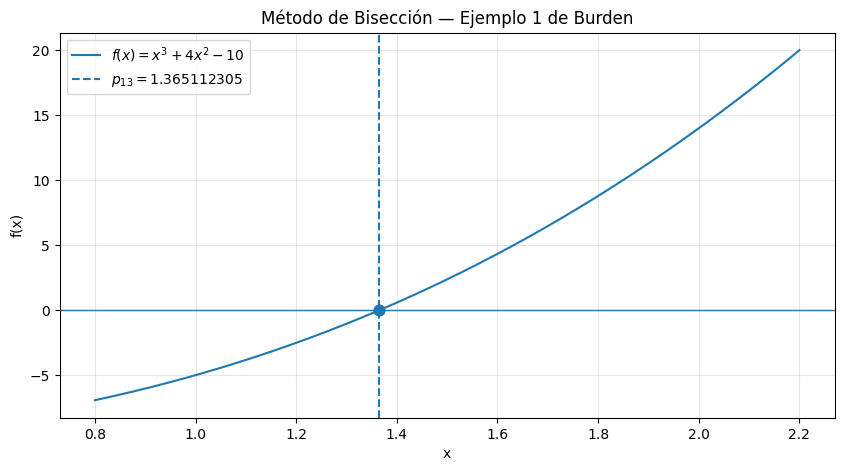

In [29]:
# Valores para construir la gráfica

x = np.linspace(0.8, 2.2, 500)

y = f(x)

p13 = tabla.iloc[12]["p"]

# Gráfica:

plt.figure(figsize=(10, 5))

plt.plot(
    x,
    y,
    label=r"$f(x)=x^3+4x^2-10$"
)

plt.axhline(
    0,
    linewidth=1
)

plt.axvline(
    p13,
    linestyle="--",
    label=fr"$p_{{13}}={p13:.9f}$"
)

plt.scatter(
    p13,
    f(p13),
    s=60
)


plt.xlabel("x")
plt.ylabel("f(x)")

plt.title(
    "Método de Bisección — Ejemplo 1 de Burden"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.show()

11. Comprobación numérica

La aproximación obtenida después de 13 iteraciones es:

$$
p_{13}=1.3651123046875
$$

Al evaluar la función en este punto:

$$
f(p_{13})
=
p_{13}^{3}+4p_{13}^{2}-10
$$

se obtiene un valor cercano a cero.

Esto confirma que $p_{13}$ se encuentra próximo a la raíz buscada.

In [30]:
print(f"p13 = {p13:.12f}")
print(f"f(p13) = {f(p13):.12f}")

p13 = 1.365112304688
f(p13) = -0.001943659010


12. Resultado final

La aproximación de la raíz de

$$
x^3+4x^2-10=0
$$

mediante el método de bisección es:

$$
\boxed{\displaystyle x\approx1.365112305}
$$

Por lo tanto, con cuatro cifras decimales:

$$
\boxed{\displaystyle x\approx1.3651}
$$

*Conclusión*

El método de bisección fue implementado siguiendo la estructura del **Algoritmo 2.1 de Burden**.

A partir del intervalo inicial

$$
[1,2]
$$

se verificó que existe un cambio de signo:

$$
f(1)f(2)<0
$$

y posteriormente se redujo sucesivamente el intervalo mediante el cálculo de puntos medios.

Después de 13 iteraciones se obtuvo la aproximación:

$$
\boxed{p_{13}=1.365112305}
$$

la cual coincide con el valor reportado en el Ejemplo 1 de Burden.

El método resulta ser un procedimiento para aproximar raíces cuando se dispone de un intervalo inicial en el que la función presenta un cambio de signo.